In [1]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

# Trỏ path về thư mục gốc của project (chứa core/ và utils/)
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from core.segmentor import Segmentor
from core.depth_estimator import DepthEstimator
from core.geometry_copy import GeometryEngine

# Hàm helper để show ảnh trên matplotlib
def imshow(img_bgr, title="Image", cmap=None, alpha=1.0):
    if len(img_bgr.shape) == 3:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img_bgr
    plt.imshow(img_rgb, cmap=cmap, alpha=alpha)
    plt.title(title)
    plt.axis('off')

print("Môi trường đã sẵn sàng!")

xFormers not available
xFormers not available


Môi trường đã sẵn sàng!


Kích thước ảnh: 1920x1080
[Segmentor] Loaded YOLO model từ e:\PNKX\anomaly_detection\weights/best_yolov8l.pt
[Segmentor] Phát hiện 3 đối tượng với conf >= 0.2
[Segmentor] Phát hiện: sidewalk (ID: 2) - Conf: 0.92
[Segmentor] Phát hiện: road (ID: 1) - Conf: 0.92
[Segmentor] Phát hiện: building (ID: 3) - Conf: 0.71


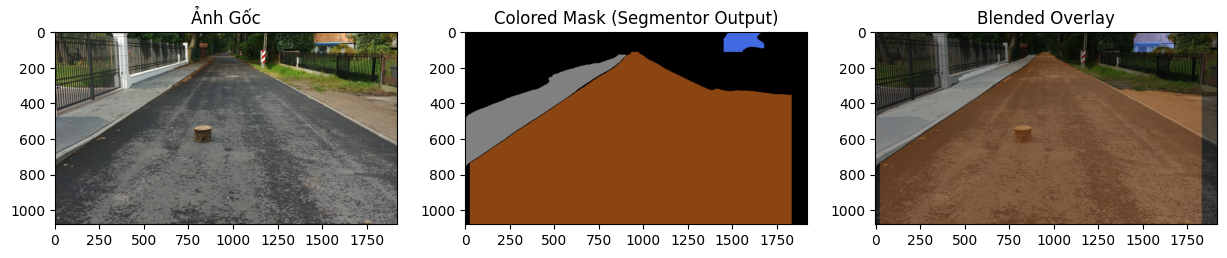

In [2]:
# Load ảnh test
image_path = os.path.join(PROJECT_ROOT, "dataset_ObstacleTrack/images/darkasphalt_stump_1.webp") # Hãy đảm bảo bạn có ảnh này ở thư mục gốc
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Không tìm thấy ảnh tại: {image_path}")

H, W = img_bgr.shape[:2]
print(f"Kích thước ảnh: {W}x{H}")

# Khởi tạo Segmentor
yolo_weight = os.path.join(PROJECT_ROOT, "weights/best_yolov8l.pt") # Hãy đảm bảo bạn có file trọng số này ở thư mục gốc
segmentor = Segmentor(weight_path=yolo_weight)

# Chạy suy luận lấy road mask
colored_mask = segmentor.predict(img_bgr, conf_threshold=0.2)

# Để hiển thị bằng matplotlib, cần chuyển từ BGR sang RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
colored_mask_rgb = cv2.cvtColor(colored_mask, cv2.COLOR_BGR2RGB)

# Tạo ảnh blend (chồng mask lên ảnh thật với độ trong suốt 50%)
alpha = 0.5
blended_img = cv2.addWeighted(img_rgb, 1 - alpha, colored_mask_rgb, alpha, 0)

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Ảnh Gốc")

plt.subplot(1, 3, 2)
plt.imshow(colored_mask_rgb)
plt.title("Colored Mask (Segmentor Output)")

plt.subplot(1, 3, 3)
plt.imshow(blended_img)
plt.title("Blended Overlay")

plt.show()

[DepthEstimator] Loaded Metric Depth (vits) trên cpu
Đang chạy suy luận DepthAnything V2 trên CPU (fx=1837.19)...
Kích thước Depth Map: (1080, 1920)
Khoảng cách Min: 0.00m | Max: 31.20m | Trung bình: 8.46m


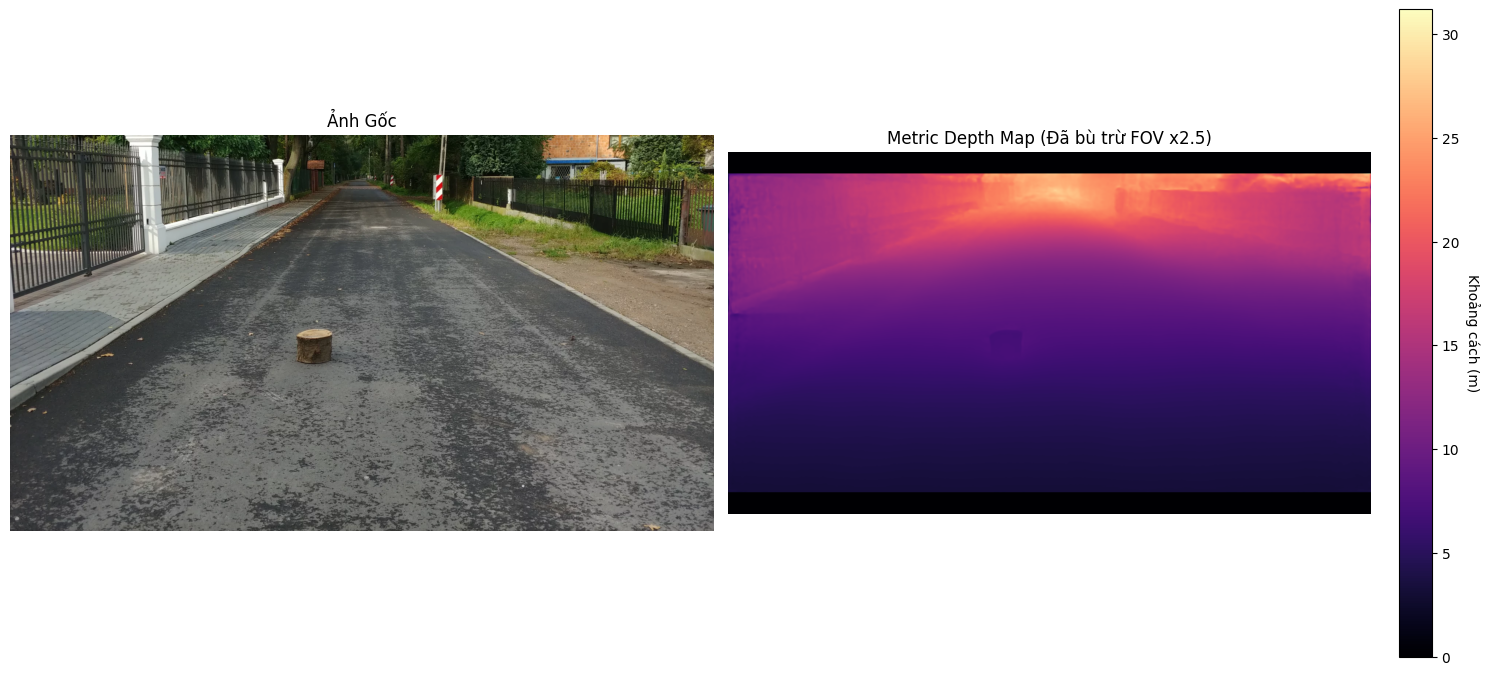

In [3]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Nếu bạn chưa load ảnh ở cell trước, hãy bỏ comment 3 dòng dưới đây:
# image_path = os.path.join(PROJECT_ROOT, "phenikax_dataset/CAM_P_F/1758620947-799749851.jpg")
# img_bgr = cv2.imread(image_path)
# img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 1. Khởi tạo Depth Estimator
depth_weight = os.path.join(PROJECT_ROOT, "weights/depth_anything_v2_metric_vkitti_vits.pth")
device = "cuda" if torch.cuda.is_available() else "cpu"

K = np.array([
    [1837.189936, 0.000000, 912.272553],
    [0.000000, 1844.888039, 728.975910],
    [0.000000, 0.000000, 1.000000]
], dtype=np.float64)

E_v2c = np.array([
    [0.050593,-0.998719,0.000873,-0.067766],
    [4.4e-05,-0.000872,-1.0,1.880442],
    [0.998719,0.050593,0.0,-1.305326],
    [0.0,0.0,0.0,1.0]
], dtype=np.float64)

geo_engine = GeometryEngine(K, E_v2c)

depth_estimator = DepthEstimator(weight_path=depth_weight, device=device)
# --- ĐIỂM QUAN TRỌNG: Khai báo tiêu cự camera hiện tại ---
# Bạn có thể lấy từ geo_engine.fx hoặc gán cứng số của CAM_P_F
current_fx = 1837.189936  

# 2. Chạy suy luận lấy metric depth map (CÓ KÍCH HOẠT BÙ TRỪ FOV)
print(f"Đang chạy suy luận DepthAnything V2 trên {device.upper()} (fx={current_fx:.2f})...")


depth_map = depth_estimator.predict(img_bgr, K=geo_engine.K)

# In ra thống kê để kiểm tra xem model có trả về đơn vị mét hợp lý không
print(f"Kích thước Depth Map: {depth_map.shape}")
print(f"Khoảng cách Min: {depth_map.min():.2f}m | Max: {depth_map.max():.2f}m | Trung bình: {depth_map.mean():.2f}m")

# 3. Visualize
plt.figure(figsize=(15, 7))

# Ảnh gốc
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Ảnh Gốc")
plt.axis('off')

# Depth Map
plt.subplot(1, 2, 2)
# Sử dụng colormap 'magma' hoặc 'plasma'
im = plt.imshow(depth_map, cmap='magma')
plt.title(f"Metric Depth Map (Đã bù trừ FOV x{(current_fx/725.0087):.1f})")
plt.axis('off')

# Thêm thanh màu (colorbar)
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Khoảng cách (m)', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

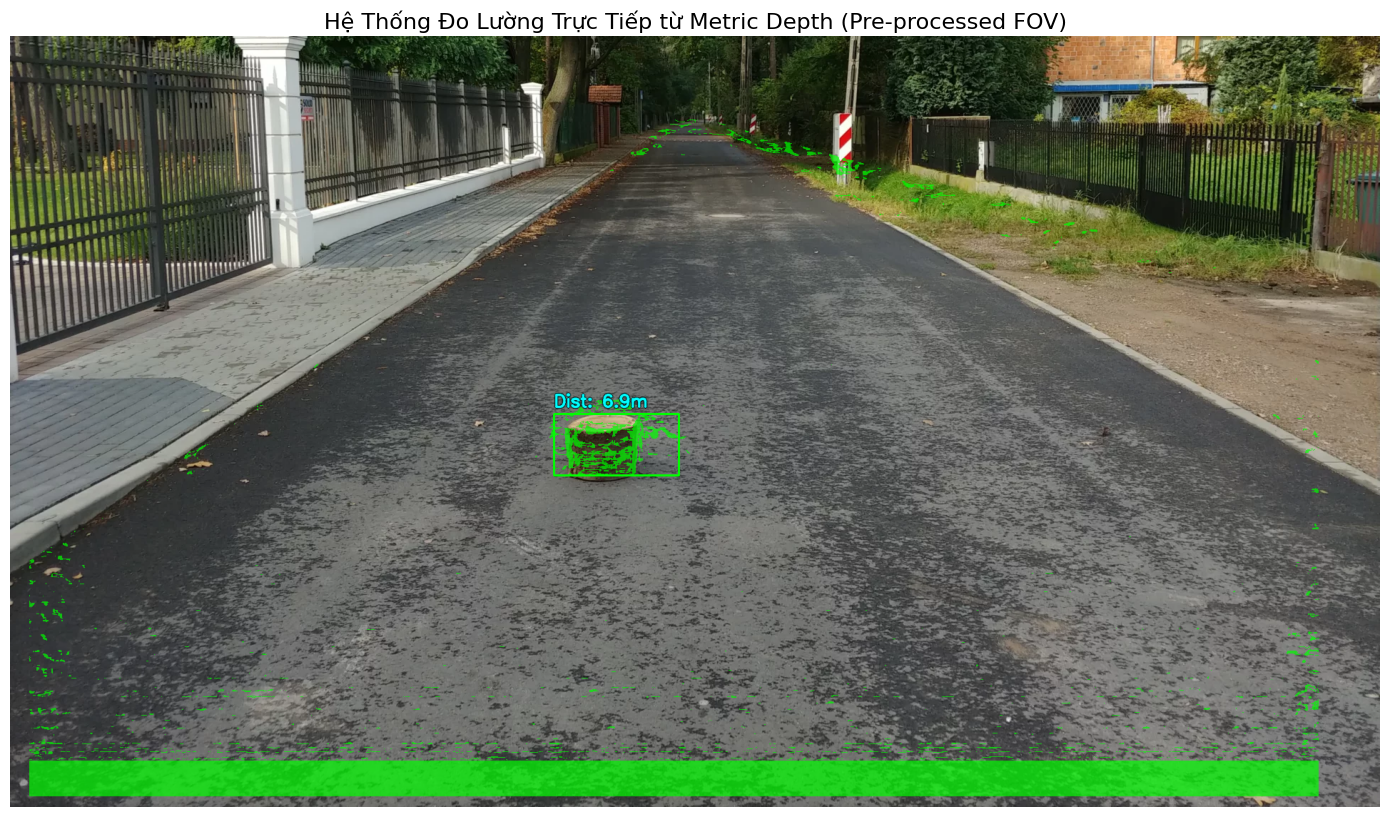

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# --- 1. SETUP THÔNG SỐ (Chỉ dùng để tính Vector Pháp tuyến) ---


# --- 2. XỬ LÝ ẢNH & BÓC TÁCH VẬT CẢN ---
road_bgr_color = (19, 69, 139)
road_mask_bool = np.all(colored_mask == road_bgr_color, axis=-1)
alpha_mask = geo_engine.get_alpha_shape_mask_cv2(road_mask_bool)

# Lọc vật cản trực tiếp từ bản đồ Depth CHUẨN HÓA
# Vì depth_map_real có hình khối chuẩn, vector pháp tuyến sẽ cắt cực kỳ nét!
normal_mask, _ = geo_engine.get_obstacle_mask_normals_numpy(depth_map, alpha_mask, angle_thr_deg=60)

# --- 3. TRỰC QUAN HÓA VÀ TRÍCH XUẤT KHOẢNG CÁCH ---
plt.figure(figsize=(14, 10))
result_final = img_rgb.copy()

# Phủ màu xanh lá mờ lên vùng vật cản
color_obs_rgb = np.array([0, 255, 0])
result_final[normal_mask] = (result_final[normal_mask] * 0.3 + color_obs_rgb * 0.7).astype(np.uint8)

contours, _ = cv2.findContours(normal_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    if cv2.contourArea(cnt) > 500 and cv2.contourArea(cnt) < 50000:  # Lọc theo diện tích để tránh nhiễu quá nhỏ hoặc quá lớn
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(result_final, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # CẢI TIẾN TRÍCH XUẤT: Chỉ lấy nửa dưới của Bounding Box
        # Lý do: Phần trên của xe thường là kính (xuyên thấu) hoặc bị lẹm vào bầu trời,
        # Nửa dưới (thân xe, gầm xe, lốp xe) là khối đặc mang khoảng cách chuẩn nhất.
        half_h = h // 2
        y_lower = y + half_h
        
        # Lấy mask của riêng vật thể này trong giới hạn nửa dưới
        roi_mask = normal_mask[y_lower:y+h, x:x+w]
        
        # Trích xuất toàn bộ các điểm ảnh (pixels) độ sâu thuộc về vật thể
        Z_c_roi = depth_map[y_lower:y+h, x:x+w][roi_mask]
        
        if len(Z_c_roi) > 0:
            # Lấy trung vị (Median) để loại bỏ hoàn toàn các điểm nhiễu ngoại lai
            real_distance = np.min(Z_c_roi)
            
            # Ghi khoảng cách lên ảnh
            label_dist = f"Dist: {real_distance:.1f}m"
            text_y = max(30, y - 10)
            
            # Viết viền đen chữ vàng cho dễ đọc trên mọi nền
            cv2.putText(result_final, label_dist, (x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 4, cv2.LINE_AA)
            cv2.putText(result_final, label_dist, (x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2, cv2.LINE_AA)
    else:
        continue  # Bỏ qua những contour quá nhỏ hoặc quá lớn, tránh nhiễu
plt.imshow(result_final)
plt.title("Hệ Thống Đo Lường Trực Tiếp từ Metric Depth (Pre-processed FOV)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# [Markdown] ## 5. Visualize Toàn Cảnh 3D bằng Open3D

import open3d as o3d
import numpy as np

def visualize_full_scene_3d(img_rgb: np.ndarray, depth_map: np.ndarray, K: np.ndarray):
    """
    Dựng hình và Visualize toàn bộ không gian 3D từ ảnh màu và Depth map.
    """
    print("Đang dựng hình không gian 3D... (Cửa sổ Open3D sẽ hiện lên)")
    
    # 1. Chuyển đổi Numpy array sang format Image của Open3D
    # Ép kiểu float32 cho depth để giữ nguyên độ chính xác (đơn vị: mét)
    color_o3d = o3d.geometry.Image(img_rgb)
    depth_o3d = o3d.geometry.Image(depth_map.astype(np.float32))

    # 2. Tạo đối tượng RGBD (Ảnh màu kèm độ sâu)
    # depth_scale=1.0 vì bản đồ của chúng ta đã tính bằng mét
    # depth_trunc=50.0: Cắt bỏ các điểm xa hơn 50 mét (như bầu trời) để tránh nhiễu
    rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
        color_o3d, depth_o3d, 
        depth_scale=1.0, 
        depth_trunc=50.0, 
        convert_rgb_to_intensity=False
    )

    # 3. Khởi tạo Thông số Camera cho Open3D
    H, W = depth_map.shape
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    intrinsic = o3d.camera.PinholeCameraIntrinsic(W, H, fx, fy, cx, cy)

    # 4. Tạo Point Cloud (Đám mây điểm)
    pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_image, intrinsic)

    # 5. Xoay trục tọa độ (Để dễ nhìn)
    # Hệ tọa độ OpenCV: Trục Y hướng xuống đất, Z hướng ra xa. 
    # Ta lật trục Y và Z lại để khi mở lên, mặt đường nằm ở dưới, bầu trời nằm ở trên
    transform = [[1, 0, 0, 0],
                 [0, -1, 0, 0],
                 [0, 0, -1, 0],
                 [0, 0, 0, 1]]
    pcd.transform(transform)

    # Lọc bỏ các điểm nhiễu lưa thưa để Point Cloud nhìn sạch sẽ hơn (Tùy chọn)
    pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

    # 6. Mở cửa sổ Visualize
    # Phím tắt trong Open3D: Giữ chuột trái để xoay, lăn chuột để zoom, giữ Ctrl + chuột trái để di chuyển
    o3d.visualization.draw_geometries([pcd], window_name="Toàn cảnh 3D - Obstacle Detection")

# --- THỰC THI ---
# Truyền vào ảnh gốc, bản đồ depth ĐÃ ĐƯỢC SCALE, và ma trận Intrinsics
visualize_full_scene_3d(img_rgb, depth_map, geo_engine.K)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Đang dựng hình không gian 3D... (Cửa sổ Open3D sẽ hiện lên)


In [6]:
np.arctan(1536 / 2 / 1844) * 180 / np.pi *2 # Tính FOV ngang thực tế từ tiêu cự hiện tại

np.float64(45.22207870105315)

In [7]:
"""
Vẽ 2 Camera FOV Frustum bằng Open3D
=====================================
FOV 1 (Xanh lam) : HFoV=81°, VFoV=29°  ← "Canvas" sau khi padding+crop
FOV 2 (Cam)      : HFoV=55°, VFoV=45°  ← Camera gốc 1920x1536

Yêu cầu: pip install open3d numpy
Chạy   : python visualize_fov.py
"""

import numpy as np
import open3d as o3d


# ─────────────────────────────────────────────
# Hàm tạo frustum wireframe từ HFoV và VFoV
# ─────────────────────────────────────────────
def make_frustum(hfov_deg: float,
                 vfov_deg: float,
                 near: float = 0.3,
                 far: float = 6.0,
                 color: list = [0, 0, 1]) -> o3d.geometry.LineSet:
    """
    Trả về LineSet hình chóp cụt (frustum) trong không gian camera:
      - Trục Z  : hướng trước (depth)
      - Trục X  : sang phải
      - Trục Y  : xuống (quy ước camera thông thường)

    Tham số
    -------
    hfov_deg : góc nhìn ngang (độ)
    vfov_deg : góc nhìn dọc  (độ)
    near     : khoảng cách mặt cắt gần  (m)
    far      : khoảng cách mặt cắt xa   (m)
    color    : màu [R, G, B] ∈ [0, 1]
    """
    h = np.radians(hfov_deg / 2)
    v = np.radians(vfov_deg / 2)

    def corners(d):
        x = d * np.tan(h)
        y = d * np.tan(v)
        return [
            [ x,  y, d],   # 0: bottom-right
            [-x,  y, d],   # 1: bottom-left
            [-x, -y, d],   # 2: top-left
            [ x, -y, d],   # 3: top-right
        ]

    # Đỉnh camera (gốc tọa độ)
    apex = [0.0, 0.0, 0.0]

    near_pts = corners(near)   # 4 điểm mặt cắt gần  (index 1-4)
    far_pts  = corners(far)    # 4 điểm mặt cắt xa   (index 5-8)

    # 9 điểm: apex(0) + near×4 + far×4
    points = [apex] + near_pts + far_pts

    # Các cạnh wireframe
    edges = [
        # 4 tia từ apex đến góc far
        [0, 5], [0, 6], [0, 7], [0, 8],
        # Khung mặt near
        [1, 2], [2, 3], [3, 4], [4, 1],
        # Khung mặt far
        [5, 6], [6, 7], [7, 8], [8, 5],
        # Cạnh nối near ↔ far
        [1, 5], [2, 6], [3, 7], [4, 8],
    ]

    ls = o3d.geometry.LineSet()
    ls.points = o3d.utility.Vector3dVector(points)
    ls.lines  = o3d.utility.Vector2iVector(edges)
    ls.colors = o3d.utility.Vector3dVector([color] * len(edges))
    return ls


# ─────────────────────────────────────────────
# Tạo lưới tọa độ XZ (mặt đất)
# ─────────────────────────────────────────────
def make_ground_grid(size: float = 6.0,
                     step: float = 1.0) -> o3d.geometry.LineSet:
    pts, lines = [], []
    idx = 0
    vals = np.arange(-size, size + step, step)

    for v in vals:
        # Đường song song trục Z
        pts.append([ v, 0, -size])
        pts.append([ v, 0,  size])
        lines.append([idx, idx + 1]); idx += 2
        # Đường song song trục X
        pts.append([-size, 0,  v])
        pts.append([ size, 0,  v])
        lines.append([idx, idx + 1]); idx += 2

    ls = o3d.geometry.LineSet()
    ls.points = o3d.utility.Vector3dVector(pts)
    ls.lines  = o3d.utility.Vector2iVector(lines)
    ls.colors = o3d.utility.Vector3dVector(
        [[0.55, 0.55, 0.55]] * len(lines))
    return ls


# ─────────────────────────────────────────────
# Nhãn chú thích (sphere nhỏ thay icon)
# ─────────────────────────────────────────────
def label_sphere(pos, radius=0.06, color=[1, 1, 1]):
    s = o3d.geometry.TriangleMesh.create_sphere(radius=radius)
    s.translate(pos)
    s.paint_uniform_color(color)
    s.compute_vertex_normals()
    return s


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
def main():
    # ── Thông số 2 FOV ──────────────────────
    fov_canvas = dict(hfov_deg=81.0, vfov_deg=29.0,
                      near=0.3, far=6.0,
                      color=[0.22, 0.56, 0.94])   # Xanh lam

    fov_origin = dict(hfov_deg=55.0, vfov_deg=45.0,
                      near=0.3, far=6.0,
                      color=[0.97, 0.55, 0.18])   # Cam

    # ── Tạo geometry ────────────────────────
    frustum_canvas = make_frustum(**fov_canvas)
    frustum_origin = make_frustum(**fov_origin)
    ground         = make_ground_grid(size=7.0, step=1.0)

    # Trục tọa độ tại gốc camera
    axes = o3d.geometry.TriangleMesh.create_coordinate_frame(
        size=0.5, origin=[0, 0, 0])

    # Điểm đánh dấu góc xa mỗi FOV (để dễ phân biệt)
    h_deg = fov_canvas['hfov_deg'] / 2
    v_deg = fov_canvas['vfov_deg'] / 2
    d = fov_canvas['far']
    markers_canvas = [
        label_sphere([ d*np.tan(np.radians(h_deg)),
                       d*np.tan(np.radians(v_deg)), d],
                     color=[0.22, 0.56, 0.94]),
    ]

    h_deg2 = fov_origin['hfov_deg'] / 2
    v_deg2 = fov_origin['vfov_deg'] / 2
    markers_origin = [
        label_sphere([ d*np.tan(np.radians(h_deg2)),
                       d*np.tan(np.radians(v_deg2)), d],
                     color=[0.97, 0.55, 0.18]),
    ]

    # ── Hiển thị ────────────────────────────
    geoms = ([frustum_canvas, frustum_origin, ground, axes]
             + markers_canvas + markers_origin)

    print("=" * 50)
    print("  FOV Visualizer — Open3D")
    print("=" * 50)
    print(f"  [Xanh] Canvas : HFoV={fov_canvas['hfov_deg']}°, "
          f"VFoV={fov_canvas['vfov_deg']}°")
    print(f"  [Cam]  Gốc    : HFoV={fov_origin['hfov_deg']}°, "
          f"VFoV={fov_origin['vfov_deg']}°")
    print()
    print("  Điều hướng:")
    print("    Chuột trái  = xoay")
    print("    Chuột phải  = zoom")
    print("    Chuột giữa  = pan")
    print("    Q / Esc     = thoát")
    print("=" * 50)

    o3d.visualization.draw_geometries(
        geoms,
        window_name="FOV Comparison — Canvas(81×29°) vs Origin(55×45°)",
        width=1280,
        height=720,
        lookat  = [0.0, 0.0, 3.0],
        up      = [0.0, -1.0, 0.0],
        front   = [0.0, -0.3, -1.0],
        zoom    = 0.55,
    )


if __name__ == "__main__":
    main()

  FOV Visualizer — Open3D
  [Xanh] Canvas : HFoV=81.0°, VFoV=29.0°
  [Cam]  Gốc    : HFoV=55.0°, VFoV=45.0°

  Điều hướng:
    Chuột trái  = xoay
    Chuột phải  = zoom
    Chuột giữa  = pan
    Q / Esc     = thoát
